<span style="font-weight:bold; font-size: 3rem; color:#333;">- Part 04: Batch inference for Train Delay Data (Two-Stage Model)</span>

## 🗒️ Overview

This notebook downloads a stored model and uses it to perform batch inference.

It performs the following steps:

1. 


### 📝 Imports

In [1]:
# top of notebook
from features import (
    build_features,
    add_calendar_features,
    add_train_lag_features,
    add_station_network_state_features,
    detect_trigger_time,
    add_reactive_early_dynamics,
    add_weather_rolling_features_if_present,
    add_station_delay_features,
    ensure_event_time,
    add_cause_flags,
    add_station_congestion_features,
    build_duration_baseline,
)


In [2]:
import os
import datetime
import pandas as pd
import requests
import hopsworks_utils
import datetime as dt
from dotenv import load_dotenv
#import hopsworks
from typing import Any, Dict, List, Optional, Tuple


# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

load_dotenv()

True

## 📡 Connect to Hopsworks Feature Store

In [3]:
# Optional: Hopsworks storage (not required)
try:
    project = hopsworks_utils.HopsworksInterface()
    print("Hopsworks login OK")
except Exception as e:
    project = None
    print("Hopsworks not configured / login failed (OK). Proceeding without it.")
    print("Reason:", repr(e))

#train_feature_df = project.get("train_stop_events_labeled")

#uncoment the below line when weather features are stored
#weather_df = project.get("weather_features") 


HOPSWORKS_API_KEY exists: True
HOPSWORKS_API_KEY length: 81
2026-01-11 17:46:51,356 INFO: Initializing external client
2026-01-11 17:46:51,357 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-01-11 17:46:52,512 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/2182
Hopsworks login OK


In [4]:
import os
import json
import datetime as dt
from typing import Optional, Dict, Any, List

import numpy as np
import pandas as pd
import joblib


## 📥 Inputs

This notebook runs **batch inference** (no training) using:

- A **canonical events table**: `train_stop_events_labeled.parquet` (from Part 01), filtered to an inference window  
  *(or you can point to any new ops/events parquet with the same schema).*
- The **same feature engineering** as Part 02 (copied here to avoid train/serve skew).
- Trained model artifacts produced by Part 03.

**Output:** `predictions.parquet` / `predictions.csv` with:
- keys: `train_id`, `station_code`, `event_time`
- `risk_delay_soon` (calibrated if calibrator exists)
- `p50_delay`, `p90_delay` (post-trigger only)
- `outlook_status` = `PRE` / `POST`


In [5]:
import pandas as pd
import numpy as np
import datetime as dt
import os

# -----------------------------
# Configuration
# -----------------------------
FG_NAME = "train_stop_events_labeled"

# Optional: restrict inference to a window (UTC naive timestamps).
INFER_START = os.getenv("INFER_START", "")  
INFER_END   = os.getenv("INFER_END", "")    
DEFAULT_LOOKBACK_DAYS = int(os.getenv("DEFAULT_LOOKBACK_DAYS", "7"))

HORIZON_MIN = int(os.getenv("HORIZON_MIN", "60"))
DELAY_THRESHOLD_MIN = int(os.getenv("DELAY_THRESHOLD_MIN", "10"))
# Rolling windows for network-state features
ROLL_WINDOWS_MIN = [1440, 1440*2]   # minutes
WEATHER_ROLL_WINDOWS_H = [3, 6]  # hours 
# -----------------------------
# 1. Load Data
# -----------------------------
#if os.path.exists(CANONICAL_PATH):
#    print(f"Loading data from {CANONICAL_PATH}...")
#    df = pd.read_parquet(CANONICAL_PATH)
#else:
#    raise FileNotFoundError(f"Could not find input file at {CANONICAL_PATH}.")
df = project.get(FG_NAME)
# 2. Convert timestamps
if "event_time" in df.columns:
    df["event_time"] = pd.to_datetime(df["event_time"])

# 3. Filter Window (Batch Inference Logic)
if INFER_START and INFER_END:
    print(f"Filtering for window: {INFER_START} to {INFER_END}")
    mask = (df["event_time"] >= pd.to_datetime(INFER_START)) & (df["event_time"] < pd.to_datetime(INFER_END))
    df = df.loc[mask].copy()
else:
    print(f"No explicit window set. Selecting last {DEFAULT_LOOKBACK_DAYS} days.")
    max_time = df["event_time"].max()
    min_time = max_time - pd.Timedelta(days=DEFAULT_LOOKBACK_DAYS)
    df = df.loc[df["event_time"] >= min_time].copy()

print(f"✅ Data ready for inference. Rows: {len(df)}")

# -----------------------------
# 4. FIX: Rename & Print Weather
# -----------------------------
print("\n🔍 Checking for weather columns...")

# Map raw names to what features.py expects
weather_rename_map = {
    "temperature_2m": "weather_temperature_2m",
    "precipitation": "weather_precipitation",
    "rain": "weather_rain",
    "snowfall": "weather_snowfall",
    "windspeed_10m": "weather_windspeed_10m"
}

# Apply renaming
renamed_count = 0
for old_name, new_name in weather_rename_map.items():
    if old_name in df.columns:
        df.rename(columns={old_name: new_name}, inplace=True)
        renamed_count += 1

# Verify results
current_weather_cols = [c for c in df.columns if c.startswith("weather_")]

if current_weather_cols:
    print(f"✅ Success! Found and renamed {len(current_weather_cols)} weather columns.")
    print("Columns:", current_weather_cols)
    print("\nSample Weather Data:")
    display(df[current_weather_cols].head(5))
else:
    print("❌ WARNING: No weather columns found. Check if 'temperature_2m' etc. exist in the feature group.")
    print("Available columns:", list(df.columns))

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (5.33s) 
No explicit window set. Selecting last 7 days.
✅ Data ready for inference. Rows: 70743

🔍 Checking for weather columns...
✅ Success! Found and renamed 6 weather columns.
Columns: ['weather_temperature_2m', 'weather_precipitation', 'weather_rain', 'weather_snowfall', 'weather_windspeed_10m', 'weather_time']

Sample Weather Data:


,weather_temperature_2m,weather_precipitation,weather_rain,weather_snowfall,weather_windspeed_10m,weather_time
0,-2.0,0.0,0.0,0.0,8.4,2026-01-08 23:00:00
1,-2.0,0.0,0.0,0.0,8.4,2026-01-08 23:00:00
2,-2.0,0.0,0.0,0.0,8.4,2026-01-08 23:00:00
3,-2.0,0.0,0.0,0.0,8.4,2026-01-08 23:00:00
4,-2.0,0.0,0.0,0.0,8.4,2026-01-08 23:00:00


## 🧱 Feature engineering (identical to Part 02)

In [6]:
# --- Feature Engineering Phase ---
# We use the shared logic from features.py to ensure 
# Training and Inference generate the exact same columns.

print("⚡️ Engineering features using 'features.py'...")

# 1. Clean & Rename (Safety Check)
# Ensure weather columns are named correctly before starting
weather_rename_map = {
    "temperature_2m": "weather_temperature_2m",
    "precipitation": "weather_precipitation",
    "rain": "weather_rain",
    "snowfall": "weather_snowfall",
    "windspeed_10m": "weather_windspeed_10m"
}
existing_rename = {k: v for k, v in weather_rename_map.items() if k in df.columns}
if existing_rename:
    df = df.rename(columns=existing_rename)

# 2. Build Features
# This one function call does ALL the math (Calendar, Lags, Rolling, Weather)
df_feat = build_features(df, WEATHER_ROLL_WINDOWS_H, ROLL_WINDOWS_MIN)

print("✅ Feature engineering complete.")
print("Feature table shape:", df_feat.shape)
display(df_feat.head())

⚡️ Engineering features using 'features.py'...
✅ Feature engineering complete.
Feature table shape: (70743, 64)


,event_time,activityid,activitytype,train_id,scheduled_time,estimated_time,actual_time,observed_time,station_code,delay_min,...,weather_precipitation_rollmean_3h,weather_rain_rollmean_3h,weather_snowfall_rollmean_3h,weather_windspeed_10m_rollmean_3h,weather_temperature_2m_rollmean_6h,weather_precipitation_rollmean_6h,weather_rain_rollmean_6h,weather_snowfall_rollmean_6h,weather_windspeed_10m_rollmean_6h,station_avg_delay
0,2026-01-08 23:29:00+01:00,1500adde-075d-66fb-08de-4372b55866ce,Avgang,10994,2026-01-08 23:29:00,NaT,2026-01-08 23:31:00,2026-01-08 23:31:00,Arnc,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.970359
1,2026-01-08 23:29:00+01:00,1500adde-075d-66fb-08de-4372b55866cd,Ankomst,10994,2026-01-08 23:29:00,NaT,2026-01-08 23:29:00,2026-01-08 23:29:00,Arnc,0.0,...,0.0,0.0,0.0,8.4,-2.0,0.0,0.0,0.0,8.4,7.970359
2,2026-01-08 23:44:00+01:00,1500adde-075d-66fb-08de-4372fec1abd9,Ankomst,2285,2026-01-08 23:44:00,NaT,2026-01-08 23:42:00,2026-01-08 23:42:00,Arnc,-2.0,...,0.0,0.0,0.0,8.4,-2.0,0.0,0.0,0.0,8.4,7.970359
3,2026-01-08 23:44:00+01:00,1500adde-075d-66fb-08de-4372fec1abda,Avgang,2285,2026-01-08 23:44:00,NaT,2026-01-08 23:44:00,2026-01-08 23:44:00,Arnc,0.0,...,0.0,0.0,0.0,8.4,-2.0,0.0,0.0,0.0,8.4,7.970359
4,2026-01-09 03:44:00+01:00,1500adde-075d-66fb-08de-4372f5d3babe,Ankomst,2205,2026-01-09 03:44:00,NaT,2026-01-09 03:44:00,2026-01-09 03:44:00,Arnc,0.0,...,NaN,NaN,NaN,NaN,-2.0,0.0,0.0,0.0,8.4,7.970359


In [7]:
import pandas as pd
import numpy as np
import os
from typing import Optional

def load_inference_events(fg_name: str) -> pd.DataFrame:
    #if not os.path.exists(path):
    #    raise FileNotFoundError(f"Could not find inference dataset at: {path}")
    #d = pd.read_parquet(path)
    d = project.get(fg_name)
    if "event_time" not in d.columns:
        raise ValueError("Expected column 'event_time' in canonical dataset.")
    d["event_time"] = pd.to_datetime(d["event_time"], errors="coerce")
    d = d.dropna(subset=["event_time"]).copy()
    return d

def parse_ts(s: str) -> Optional[pd.Timestamp]:
    s = (s or "").strip()
    if not s:
        return None
    return pd.to_datetime(s, errors="raise")

# 1. Load Data
events = load_inference_events(FG_NAME)

# --- CRITICAL FIX: RENAME WEATHER COLUMNS ---
# This ensures features.py can find them later
weather_rename_map = {
    "temperature_2m": "weather_temperature_2m",
    "precipitation": "weather_precipitation",
    "rain": "weather_rain",
    "snowfall": "weather_snowfall",
    "windspeed_10m": "weather_windspeed_10m"
}
# Only rename if they exist (safe check)
existing_rename = {k: v for k, v in weather_rename_map.items() if k in events.columns}
if existing_rename:
    print(f"🔄 Renaming {len(existing_rename)} weather columns for consistency.")
    events = events.rename(columns=existing_rename)
# ---------------------------------------------

# 2. Filter to inference window
start_ts = parse_ts(INFER_START)
end_ts = parse_ts(INFER_END)

if start_ts is not None:
    events = events[events["event_time"] >= start_ts]
if end_ts is not None:
    events = events[events["event_time"] < end_ts]

if start_ts is None and end_ts is None:
    # default: last DEFAULT_LOOKBACK_DAYS present in data
    max_t = events["event_time"].max()
    min_t = max_t - pd.Timedelta(days=DEFAULT_LOOKBACK_DAYS)
    events = events[events["event_time"] >= min_t]
    print(f"No INFER_START/INFER_END set -> using last {DEFAULT_LOOKBACK_DAYS} days: {min_t} → {max_t}")

events = events.sort_values(["event_time", "station_code", "train_id"]).reset_index(drop=True)
print("Inference rows:", len(events))

# 3. Verify Weather Columns exist
w_cols = [c for c in events.columns if "weather_" in c]
print(f"✅ Active Weather Columns: {w_cols}")

display(events.head())

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (4.47s) 
🔄 Renaming 5 weather columns for consistency.
No INFER_START/INFER_END set -> using last 7 days: 2026-01-05 11:58:00 → 2026-01-12 11:58:00
Inference rows: 70743
✅ Active Weather Columns: ['weather_temperature_2m', 'weather_precipitation', 'weather_rain', 'weather_snowfall', 'weather_windspeed_10m', 'weather_time']


,activityid,activitytype,train_id,event_time,scheduled_time,estimated_time,actual_time,observed_time,station_code,delay_min,...,final_delay_min,additional_delay_min,y_delay_within_horizon,weather_temperature_2m,weather_precipitation,weather_rain,weather_snowfall,weather_windspeed_10m,weather_time,source
0,1500adde-075d-66fb-08de-437328465cb5,Avgang,2983,2026-01-08 23:00:00,2026-01-08 23:00:00,NaT,2026-01-08 23:00:00,2026-01-08 23:00:00,Mr,0.0,...,0.0,0.0,0,-2.0,0.0,0.0,0.0,8.4,2026-01-08 23:00:00,archive
1,1500adde-075d-66fb-08de-4373071fa14a,Avgang,2477,2026-01-08 23:03:00,2026-01-08 23:03:00,NaT,2026-01-08 23:03:00,2026-01-08 23:03:00,Söc,0.0,...,0.0,0.0,0,-2.0,0.0,0.0,0.0,8.4,2026-01-08 23:00:00,archive
2,1500adde-075d-66fb-08de-437328465cb6,Ankomst,2983,2026-01-08 23:04:00,2026-01-08 23:04:00,NaT,2026-01-08 23:03:00,2026-01-08 23:03:00,Rs,-1.0,...,0.0,1.0,0,-2.0,0.0,0.0,0.0,8.4,2026-01-08 23:00:00,archive
3,1500adde-075d-66fb-08de-437328465cb7,Avgang,2983,2026-01-08 23:04:00,2026-01-08 23:04:00,NaT,2026-01-08 23:04:00,2026-01-08 23:04:00,Rs,0.0,...,0.0,0.0,0,-2.0,0.0,0.0,0.0,8.4,2026-01-08 23:00:00,archive
4,1500adde-075d-66fb-08de-437353752403,Avgang,7879,2026-01-08 23:05:00,2026-01-08 23:05:00,NaT,2026-01-08 23:05:00,2026-01-08 23:05:00,Arnn,0.0,...,0.0,0.0,0,-2.0,0.0,0.0,0.0,8.4,2026-01-08 23:00:00,archive


## 🧮 Build model-ready features (no leakage)

In [8]:
import json

FEATURE_METADATA_PATH = "data/feature_pipeline_outputs/feature_metadata.json"
# --- 1. Load Feature Metadata (The "Contract" from Part 2) ---
# We need to know EXACTLY which columns the model expects.
if os.path.exists(FEATURE_METADATA_PATH):
    with open(FEATURE_METADATA_PATH, "r") as f:
        meta = json.load(f)
        # These are the lists of columns we saved in Part 2
        pred_cols = meta["pred_feature_columns"]
        react_cols = meta["react_feature_columns"]
    print(f"✅ Loaded feature lists from metadata.")
    print(f"   Predictive features: {len(pred_cols)}")
    print(f"   Reactive features:   {len(react_cols)}")
else:
    raise FileNotFoundError(f"Could not find metadata at {FEATURE_METADATA_PATH}. Did Part 2 run successfully?")

# --- 2. Feature Selection Functions ---

def build_pred_dataset(df_feat: pd.DataFrame) -> pd.DataFrame:
    """
    Prepares dataset for Predictive Model.
    SAFETY: Selects ONLY the columns used in training. 
    Drops IDs, Targets (delay_min), and Dates to prevent leakage.
    """
    # Ensure all expected columns exist (fill missing with 0 if necessary)
    # This handles edge cases where a feature might be missing in a small batch
    missing = [c for c in pred_cols if c not in df_feat.columns]
    if missing:
        print(f"⚠️ Warning: Missing columns filled with 0: {missing}")
        for c in missing:
            df_feat[c] = 0
            
    # Return exactly the columns the model was trained on
    return df_feat[pred_cols].copy()

def build_react_dataset(df_feat: pd.DataFrame) -> pd.DataFrame:
    """
    Prepares dataset for Reactive Model.
    Filter: Only trains that are ALREADY delayed.
    """
    mask = df_feat["delay_min"] >= DELAY_THRESHOLD_MIN
    df_filtered = df_feat.loc[mask].copy()
    
    # Ensure columns exist
    missing = [c for c in react_cols if c not in df_filtered.columns]
    if missing:
        for c in missing:
            df_filtered[c] = 0
            
    return df_filtered[react_cols].copy()

print("✅ Feature selection logic ready.")

✅ Loaded feature lists from metadata.
   Predictive features: 50
   Reactive features:   52
✅ Feature selection logic ready.


In [9]:
# Assuming 'df_feat' is your engineered dataframe from the previous step:
events = df_feat 

# Build *predictive* feature table
pred_ds = build_pred_dataset(events)

# Build *reactive* feature table (post-trigger subset)
react_ds = build_react_dataset(events)

print("pred_ds shape:", pred_ds.shape)
print("react_ds shape:", react_ds.shape)
display(pred_ds.head())


⚠️ Warning: Missing columns filled with 0: ['roll_mean_delay_station_15m', 'roll_cnt_delay_ge_10_station_15m', 'roll_mean_delay_station_30m', 'roll_cnt_delay_ge_10_station_30m']
pred_ds shape: (70743, 50)
react_ds shape: (3746, 52)


,activityid,activitytype,delay_min,is_canceled,deleted,informationowner,deviation,fromlocation,tolocation,trackatlocation,...,weather_precipitation_rollmean_3h,weather_rain_rollmean_3h,weather_snowfall_rollmean_3h,weather_windspeed_10m_rollmean_3h,weather_temperature_2m_rollmean_6h,weather_precipitation_rollmean_6h,weather_rain_rollmean_6h,weather_snowfall_rollmean_6h,weather_windspeed_10m_rollmean_6h,station_avg_delay
0,1500adde-075d-66fb-08de-4372b55866ce,Avgang,2.0,False,False,Mälardalstrafik AB,None,Cst,"Kn,U",1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.970359
1,1500adde-075d-66fb-08de-4372b55866cd,Ankomst,0.0,False,False,Mälardalstrafik AB,None,Cst,U,1,...,0.0,0.0,0.0,8.4,-2.0,0.0,0.0,0.0,8.4,7.970359
2,1500adde-075d-66fb-08de-4372fec1abd9,Ankomst,-2.0,False,False,SL,None,U,Sci,2,...,0.0,0.0,0.0,8.4,-2.0,0.0,0.0,0.0,8.4,7.970359
3,1500adde-075d-66fb-08de-4372fec1abda,Avgang,0.0,False,False,SL,Kort tåg,U,Sci,2,...,0.0,0.0,0.0,8.4,-2.0,0.0,0.0,0.0,8.4,7.970359
4,1500adde-075d-66fb-08de-4372f5d3babe,Ankomst,0.0,False,False,SL,None,U,Söc,2,...,NaN,NaN,NaN,NaN,-2.0,0.0,0.0,0.0,8.4,7.970359


## 🤖 Load models (from Part 03)

In [10]:
PRED_MODEL_PATH = "data/models/predictive_model.pkl"
CALIBRATOR_PATH = "data/models/calibrator.pkl"
REACT_MODEL_PATH = "data/models/reactive_model.pkl"

mr = project.project.get_model_registry()
if not os.path.exists(PRED_MODEL_PATH):
    raise FileNotFoundError(
        f"Missing predictive model at {PRED_MODEL_PATH}. Run 3_train_training_pipeline first."
    )
pred_model = joblib.load(PRED_MODEL_PATH)
#pred_model = mr.get_model("predictive_model", version=1)
calibrator = None
if os.path.exists(CALIBRATOR_PATH):#TODO?
    calibrator = joblib.load(CALIBRATOR_PATH)
    print("Loaded calibrator:", CALIBRATOR_PATH)
else:
    print("No calibrator found (ok). Will use raw model probabilities.")

if not os.path.exists(REACT_MODEL_PATH):
    raise FileNotFoundError(
        f"Missing reactive model at {REACT_MODEL_PATH}. Run 3_train_training_pipeline first."
    )
react_bundle = joblib.load(REACT_MODEL_PATH)
#react_model = mr.get_model("reactive_model", version=1)
# Expect react_bundle to contain quantile models if you trained them:
# { "point": model, "q10": model, "q50": model, "q90": model } OR similar.
print("Reactive bundle keys:", list(react_bundle.keys()) if isinstance(react_bundle, dict) else type(react_bundle))


Loaded calibrator: data/models/calibrator.pkl
Reactive bundle keys: ['point']


In [12]:
import numpy as np
import pandas as pd



# ------------------------------------------------------------------
# 0) Define ID columns for output
# ------------------------------------------------------------------
id_cols = ["activityid", "train_id", "station_code"]

# Carry these along if they exist (helps early-warning filtering + debugging)
extra_cols = [c for c in ["delay_min", "min_since_trigger", "event_time"] if c in events.columns]

# ------------------------------------------------------------------
# 1) Build base table with IDs (+ extras) from events
#    Attach engineered features from pred_ds by row alignment
# ------------------------------------------------------------------
base = events[id_cols + extra_cols].copy().reset_index(drop=True)

# Drop any IDs/extras from pred_ds to avoid duplicate columns after concat
pred_feats = pred_ds.drop(columns=id_cols + extra_cols, errors="ignore").copy().reset_index(drop=True)

# Defensive: same length check
if len(base) != len(pred_feats):
    raise RuntimeError(
        f"Length mismatch: events has {len(base)} rows, pred_ds has {len(pred_feats)} rows. "
        "You need a real join key (e.g., ActivityId) carried inside pred_ds."
    )

pred_ds_full = pd.concat([base, pred_feats], axis=1)

# sanity: ensure no duplicate columns
dups = pred_ds_full.columns[pred_ds_full.columns.duplicated()].tolist()
if dups:
    raise RuntimeError(f"Duplicate columns detected after concat: {dups}")

# ------------------------------------------------------------------
# 2) Build X_pred with EXACT columns expected by the trained pipeline
# ------------------------------------------------------------------
model_for_cols = (
    calibrator if (calibrator is not None and hasattr(calibrator, "feature_names_in_"))
    else pred_model
)

if not hasattr(model_for_cols, "feature_names_in_"):
    raise RuntimeError("Cannot infer required feature columns from model.")

required_cols = list(model_for_cols.feature_names_in_)
X_pred = pred_ds_full.reindex(columns=required_cols)

# ------------------------------------------------------------------
# 3) CRITICAL SANITIZATION STEP
# ------------------------------------------------------------------
for c in X_pred.columns:
    if pd.api.types.is_datetime64_any_dtype(X_pred[c]):
        X_pred[c] = (X_pred[c].view("int64") / 1e9).astype(float)
        X_pred[c] = X_pred[c].fillna(0.0)
        continue

    if X_pred[c].dtype == "object" and ("time" in c.lower()):
        parsed = pd.to_datetime(X_pred[c], errors="coerce")
        if parsed.notna().any():
            X_pred[c] = (parsed.view("int64") / 1e9).astype(float)
            X_pred[c] = X_pred[c].fillna(0.0)
            continue

    if pd.api.types.is_numeric_dtype(X_pred[c]) or pd.api.types.is_bool_dtype(X_pred[c]):
        X_pred[c] = X_pred[c].astype(float).fillna(0.0)
    else:
        X_pred[c] = X_pred[c].apply(lambda x: "" if pd.isna(x) else str(x))


In [13]:
from features import ensure_event_time, add_station_congestion_features




events = df_feat.copy()

# (Optional but recommended) choose WHICH time defines "history"
# If you want scheduled_time as your reference:
# events["event_time"] = events["scheduled_time"]

events = ensure_event_time(events)

# IMPORTANT: include the windows your model expects
events = add_station_congestion_features(events, windows_min=[15, 30])

# Now build datasets
pred_ds  = build_pred_dataset(events)
react_ds = build_react_dataset(events)

print(pred_ds[[
    "roll_mean_delay_station_15m",
    "roll_cnt_delay_ge_10_station_15m",
    "roll_mean_delay_station_30m",
    "roll_cnt_delay_ge_10_station_30m",
]].describe().T)

roll_cols = [
    "roll_mean_delay_station_15m",
    "roll_cnt_delay_ge_10_station_15m",
    "roll_mean_delay_station_30m",
    "roll_cnt_delay_ge_10_station_30m",
]

events[roll_cols] = events[roll_cols].fillna(0.0)
X_pred[roll_cols].isna().mean()


                                    count      mean       std        min  \
roll_mean_delay_station_15m       47356.0  2.565062  5.670084 -20.847154   
roll_cnt_delay_ge_10_station_15m  47356.0  0.520019  1.159391   0.000000   
roll_mean_delay_station_30m       49576.0  2.509454  4.946107  -9.000000   
roll_cnt_delay_ge_10_station_30m  49576.0  0.971357  1.986405   0.000000   

                                       25%       50%       75%   max  
roll_mean_delay_station_15m      -0.250000  0.500000  2.714286  91.0  
roll_cnt_delay_ge_10_station_15m  0.000000  0.000000  0.000000  12.0  
roll_mean_delay_station_30m      -0.166667  0.583333  2.933333  81.0  
roll_cnt_delay_ge_10_station_30m  0.000000  0.000000  1.000000  17.0  


roll_mean_delay_station_15m         0.0
roll_cnt_delay_ge_10_station_15m    0.0
roll_mean_delay_station_30m         0.0
roll_cnt_delay_ge_10_station_30m    0.0
dtype: float64

In [ ]:
print("Predicting...")
# ------------------------------------------------------------------
# 4) Predict calibrated risk
# ------------------------------------------------------------------
if calibrator is not None and hasattr(calibrator, "predict_proba"):
    risk = calibrator.predict_proba(X_pred)[:, 1]
else:
    risk = pred_model.predict_proba(X_pred)[:, 1]

# ------------------------------------------------------------------
# 5) Build outputs: FULL + EARLY-WARNING ONLY
# ------------------------------------------------------------------
out_full = pred_ds_full[id_cols + extra_cols].copy()
out_full["risk_delay_soon"] = risk

# Ensure consistent grouping keys
out_full["train_id"] = out_full["train_id"].astype(str)
out_full["station_code"] = out_full["station_code"].astype(str)

# Early-warning filter:
# Prefer pre-trigger if available; otherwise use "not already delayed"
if "min_since_trigger" in out_full.columns:
    out_early = out_full[out_full["min_since_trigger"] < 0].copy()
elif "delay_min" in out_full.columns:
    out_early = out_full[out_full["delay_min"] < 10].copy()
else:
    # fallback: can't filter; return full
    out_early = out_full.copy()

# ------------------------------------------------------------------
# 6) Save outputs
# ------------------------------------------------------------------
out_full_fg = "predictions_full"
out_full_path_csv     = "data/predictions_full.csv"
out_early_fg = "predictions_early"
out_early_path_csv     = "data/predictions_early.csv"

#out_full.to_parquet(out_full_path_parquet, index=False)

project.push(out_full, out_full_fg, ["ActivityId"], "Full predictions")


#out_full.to_csv(out_full_path_csv, index=False)
project.push(out_early, out_early_fg, ["ActivityId"], "Early predictions")
#out_early.to_parquet(out_early_path_parquet, index=False)
#out_early.to_csv(out_early_path_csv, index=False)

print("✅ Saved predictions:")
print(out_full_fg)
print(out_early_fg)


# Show top-20 EARLY warnings (not already delayed)
out_early = out_early.sort_values("risk_delay_soon", ascending=False)
display(out_early.head(20))

#Filter out future train departures

#print(out_early.info())
#out_early["event_time"] = pd.to_datetime(out_early["event_time"], errors="coerce")
#future_pred = out_early[out_early["event_time"] > pd.Timestamp.now()]

# ------------------------------------------------------------------
# 7) Average risk per station/train (EARLY set)
# ------------------------------------------------------------------
station_avg_risk_early = (
    out_early.groupby("station_code")["risk_delay_soon"]
            .mean()
            .sort_values(ascending=False)
            .rename("station_avg_risk_early")
)

train_avg_risk_early = (
    out_early.groupby("train_id")["risk_delay_soon"]
            .mean()
            .sort_values(ascending=False)
            .rename("train_avg_risk_early")
)

display(station_avg_risk_early.head(20))
display(train_avg_risk_early.head(20))

print(station_avg_risk_early.info())

# Optional: quick sanity stats
print("Early rows:", len(out_early), "/", len(out_full))
print("Share early risk ~1.0:", (out_early["risk_delay_soon"] >= 0.999).mean() if len(out_early) else np.nan)


Predicting...
2026-01-11 17:52:00,704 INFO: Computing insert statistics
Inserted historical data into feature group "train_delay_features"
2026-01-11 17:52:16,736 INFO: Computing insert statistics
Inserted historical data into feature group "train_delay_features"
✅ Saved predictions:
predictions_full
data/predictions_full.csv
predictions_early
data/predictions_early.csv


,activityid,train_id,station_code,delay_min,min_since_trigger,event_time,risk_delay_soon
22133,1500adde-075d-66fb-08de-437365cda455,870,Kn,7.0,-9999.0,2026-01-09 22:05:00+01:00,1.0
9182,1500adde-075d-66fb-08de-4372fb069849,2249,Flb,1.0,-7.0,2026-01-09 15:43:00+01:00,1.0
63321,1500adde-075d-66fb-08de-4372fefc1eef,2311,Äs,0.0,-38.0,2026-01-09 06:08:00+01:00,1.0
607,1500adde-075d-66fb-08de-443d6e6d71da,971,Arnc,-1.0,-19.0,2026-01-10 18:28:00+01:00,1.0
30887,1500adde-075d-66fb-08de-4372ff2edfe0,2313,Sci,-1.0,-41.0,2026-01-09 06:27:00+01:00,1.0
617,1500adde-075d-66fb-08de-443d26420348,25,Arnc,4.0,-9999.0,2026-01-10 18:53:00+01:00,1.0
9123,1500adde-075d-66fb-08de-437314607820,2645,Flb,8.0,-3.0,2026-01-09 14:36:00+01:00,1.0
40660,1500adde-075d-66fb-08de-4372ff6643c7,2315,Spå,1.0,-9999.0,2026-01-09 06:43:00+01:00,1.0
39670,1500adde-075d-66fb-08de-443d3648d2e3,2727,Sol,8.0,-13.0,2026-01-10 09:14:00+01:00,1.0
9135,1500adde-075d-66fb-08de-43731bc417dc,2747,Flb,1.0,-12.0,2026-01-09 14:51:00+01:00,1.0


station_code
Arnc    0.020976
U       0.019427
Cst     0.016968
Hu      0.016817
Söö     0.016540
Sta     0.016455
Flb     0.016378
Kda     0.015532
Ts      0.015505
Hfa     0.015207
Nkv     0.014727
Söd     0.014718
Rs      0.014539
So      0.014419
Tul     0.014260
Ssä     0.013833
Mr      0.013437
Nvk     0.013195
Upv     0.013184
Hel     0.012692
Name: station_avg_risk_early, dtype: float64

train_id
7040    0.833333
442     0.433150
620     0.429281
585     0.395253
279     0.289236
2669    0.196661
576     0.193040
2769    0.183039
2544    0.172828
589     0.162493
561     0.158522
563     0.157233
2671    0.145268
674     0.141836
3940    0.120183
528     0.119649
25      0.119059
220     0.110638
428     0.104841
21      0.088600
Name: train_avg_risk_early, dtype: float64

<class 'pandas.core.series.Series'>
Index: 65 entries, Arnc to Skg
Series name: station_avg_risk_early
Non-Null Count  Dtype  
--------------  -----  
65 non-null     float64
dtypes: float64(1)
memory usage: 1.0+ KB
None
Early rows: 66211 / 70743
Share early risk ~1.0: 0.0011478455241576173


In [15]:
tmp = pred_ds_full.copy()
tmp["risk"] = risk

hi = tmp[tmp["risk"] >= 0.999]

cols = [c for c in [
    "event_time", "ActivityType", "delay_min", "reason_code",
    "trigger_time", "min_since_trigger", "is_first15m_after_trigger"
] if c in hi.columns]

display(hi[cols].head(30))

# How many high-risk are already delayed / post-trigger?
stats = {}
if "delay_min" in tmp.columns:
    stats["hi_delay_ge_10"] = (hi["delay_min"] >= 10).mean()
if "min_since_trigger" in tmp.columns:
    stats["hi_post_trigger"] = (hi["min_since_trigger"] >= 0).mean()
if "reason_code" in tmp.columns:
    stats["hi_has_reason_code"] = hi["reason_code"].notna().mean()

stats


,event_time,delay_min,min_since_trigger
85,2026-01-09 08:19:00+01:00,29.0,20.0
96,2026-01-09 08:54:00+01:00,73.0,20.0
155,2026-01-09 11:51:00+01:00,38.0,26.0
175,2026-01-09 13:08:00+01:00,24.0,18.0
266,2026-01-09 17:42:00+01:00,18.0,0.0
273,2026-01-09 18:14:00+01:00,68.0,18.0
274,2026-01-09 18:14:00+01:00,67.0,18.0
282,2026-01-09 18:44:00+01:00,42.0,18.0
283,2026-01-09 18:44:00+01:00,43.0,18.0
330,2026-01-09 21:24:00+01:00,100.0,28.0


{'hi_delay_ge_10': 0.8503311258278146, 'hi_post_trigger': 0.8993377483443709}

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.00s) 
<class 'pandas.core.frame.DataFrame'>
Index: 65 entries, Arnc to Skg
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   station_avg_risk        65 non-null     float64
 1   advertisedlocationname  65 non-null     object 
 2   wgs84                   65 non-null     object 
 3   lat                     65 non-null     float64
 4   lon                     65 non-null     float64
dtypes: float64(3), object(2)
memory usage: 3.0+ KB
None


<Figure size 1000x1000 with 0 Axes>

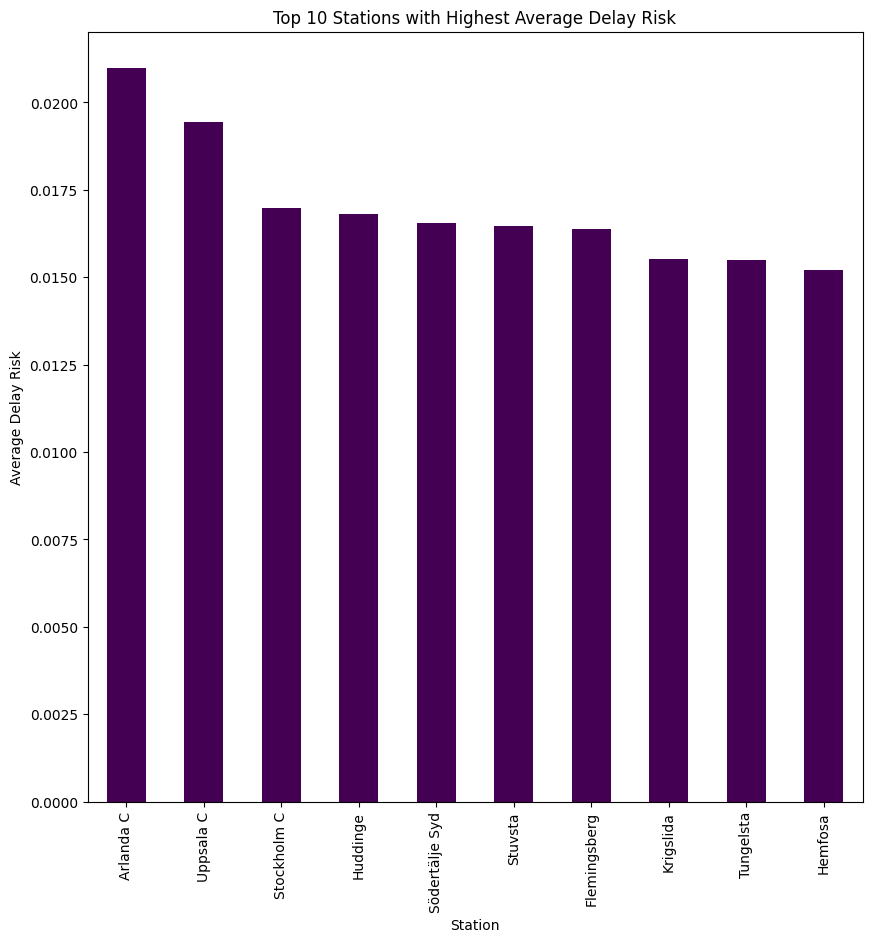

In [26]:
import pandas as pd
from typing import Any, Dict, List, Optional, Tuple
import matplotlib.pyplot as plt
import contextily as ctx
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

station_avg_risk = station_avg_risk_early
#station_df = pd.read_parquet("data/station_features.parquet")
station_df = project.get("station_features")


station_df.rename(columns={"locationsignature": "station_code"}, inplace=True)

# Merge station_avg_risk with coordinates from station_df on station_code

res = station_avg_risk.reset_index().set_index("station_code").join(
    station_df.set_index("station_code"), on=["station_code"]
)

res.rename(columns={"station_avg_risk_early": "station_avg_risk"}, inplace=True)
print(res.info())

# Create geometry
geometry = [
    Point(lon, lat) for lon, lat in zip(res["lon"], res["lat"])
]

gdf = gpd.GeoDataFrame(res, geometry=geometry, crs="EPSG:4326")

gdf = gdf.to_crs(epsg=3857)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    ax=ax,
    column="station_avg_risk",
    cmap="viridis",
    vmin=0,
    vmax=1,
    legend=True,
    legend_kwds={"label": "Predicted value"},
    markersize=50,
    alpha=0.9
)


ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)
ax.set_title("Predicted values per train station (Stockholm)")
ax.axis("off")

plt.savefig("docs/assets/img/station_delay_risk_map.png")
plt.clf()
# Bar chart of top 10 stations with highest average risk
top10 = res.sort_values("station_avg_risk", ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 10))
top10.plot(
    ax=ax,
    kind="bar",
    x="advertisedlocationname",
    y="station_avg_risk",
    #color="station_avg_risk",
    cmap="viridis",
    legend=False
)
ax.set_title("Top 10 Stations with Highest Average Delay Risk")
ax.set_xlabel("Station")
ax.set_ylabel("Average Delay Risk")
plt.savefig("docs/assets/img/top10_station_delay_risk.png")
